In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                           recall_score, f1_score, roc_auc_score, roc_curve,
                           classification_report)
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

In [2]:
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd

In [6]:
print("Loading datasets...")
# NSL-KDD
nsl_train = pd.read_csv("/content/drive/MyDrive/datasets/NSL-KDD/KDDTrain+.txt", header=None)
print("NSL-KDD Train shape:", nsl_train.shape)

# CICIDS (one file)
cicids_ddos = pd.read_csv("/content/drive/MyDrive/datasets/CICIDS/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
print("CICIDS DDoS shape:", cicids_ddos.shape)

Loading datasets...
NSL-KDD Train shape: (125973, 43)
CICIDS DDoS shape: (225745, 79)


In [7]:
nsl_columns = (['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot',
'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations',
'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate',
'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count',
'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','outcome','level'])

nsl_train.columns = nsl_columns


In [8]:
print("\n=== DATA EXPLORATION & VALIDATION ===")
print(nsl_train.head())
print("\nDataset Info:")
print(nsl_train.info())


=== DATA EXPLORATION & VALIDATION ===
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60        

In [9]:
print("\n=== MISSING DATA ANALYSIS ===")
missing_data = nsl_train.isnull().sum()
print("Missing values per column:")
print(missing_data[missing_data > 0])


=== MISSING DATA ANALYSIS ===
Missing values per column:
Series([], dtype: int64)


In [10]:
def handle_missing_data(df):
    """Advanced missing data handling"""
    df_clean = df.copy()

    # Fill numerical columns with median
    numerical_cols = df_clean.select_dtypes(include=[np.number]).columns
    for col in numerical_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)

    # Fill categorical columns with mode
    categorical_cols = df_clean.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

    return df_clean

nsl_train_clean = handle_missing_data(nsl_train)

In [11]:
print("\n=== DUPLICATE DATA HANDLING ===")
num_duplicates = nsl_train_clean.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")
nsl_train_clean = nsl_train_clean.drop_duplicates()
print(f"Shape after removing duplicates: {nsl_train_clean.shape}")


=== DUPLICATE DATA HANDLING ===
Number of duplicate rows: 0
Shape after removing duplicates: (125973, 43)


In [12]:
attack_category_map = {
    # DoS attacks
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS', 'smurf': 'DoS', 'teardrop': 'DoS',
    # Probe attacks
    'satan': 'Probe', 'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe',
    # R2L attacks
    'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L', 'multihop': 'R2L', 'phf': 'R2L',
    'spy': 'R2L', 'warezclient': 'R2L', 'warezmaster': 'R2L',
    # U2R attacks
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R', 'rootkit': 'U2R',
    # Normal
    'normal': 'Normal'
}

nsl_train_clean['attack_category'] = nsl_train_clean['level'].apply(
    lambda x: attack_category_map.get(x, 'Normal')
)


=== EXPLORATORY DATA ANALYSIS ===


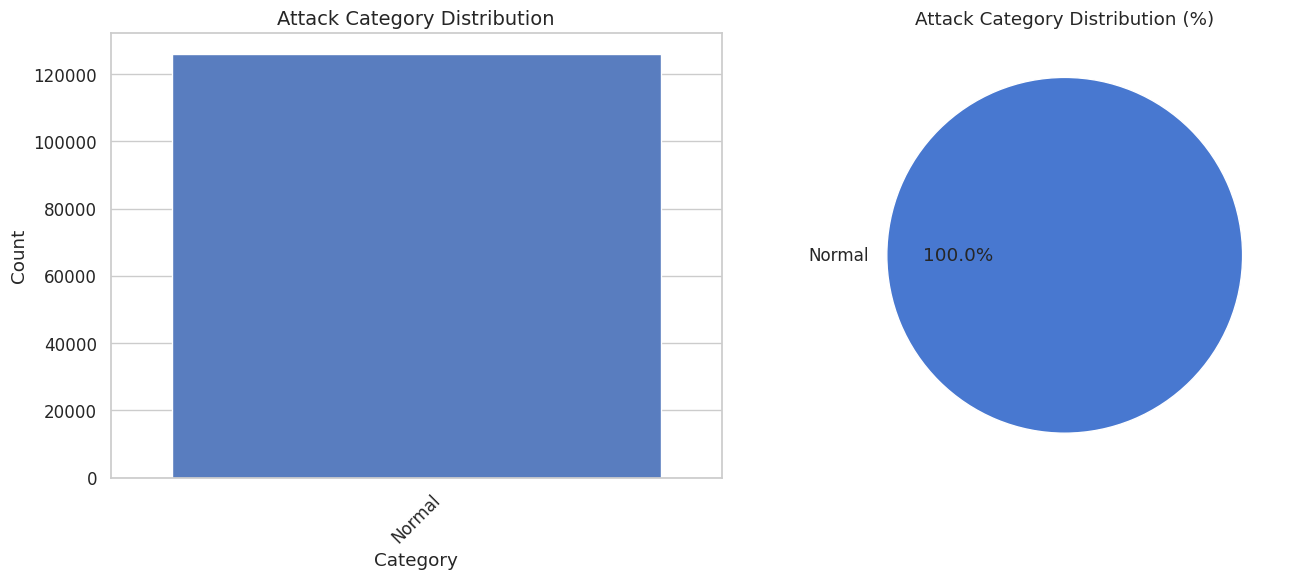

In [13]:
print("\n=== EXPLORATORY DATA ANALYSIS ===")

def plot_label_distribution(df, label_col, title):
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    df[label_col].value_counts().head(10).plot(kind='bar', color='skyblue')
    plt.title(f'{title} - Top 10')
    plt.ylabel("Count")
    plt.xlabel("Attack Type")
    plt.xticks(rotation=45)

    plt.subplot(1, 2, 2)
    df[label_col].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.title(f'{title} - Distribution')
    plt.ylabel("")

    plt.tight_layout()
    plt.show()

# Plot attack category distribution
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.countplot(data=nsl_train_clean, x="attack_category",
              order=nsl_train_clean["attack_category"].value_counts().index)
plt.title("Attack Category Distribution", fontsize=14)
plt.ylabel("Count")
plt.xlabel("Category")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
nsl_train_clean["attack_category"].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Attack Category Distribution (%)")
plt.ylabel("")

plt.tight_layout()
plt.show()

In [14]:
categorical_features = nsl_train_clean.select_dtypes(include=["object"]).columns.tolist()
numerical_features = nsl_train_clean.select_dtypes(exclude=["object"]).columns.tolist()

print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Numerical features ({len(numerical_features)}): {numerical_features[:10]}...")

Categorical features (5): ['protocol_type', 'service', 'flag', 'outcome', 'attack_category']
Numerical features (39): ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised']...


In [15]:
print("\n=== HIGH CARDINALITY ANALYSIS ===")
cardinality_info = {}
for col in categorical_features:
    unique_count = nsl_train_clean[col].nunique()
    cardinality_info[col] = unique_count
    print(f"{col}: {unique_count} unique values")

# Reduce high cardinality features
def reduce_high_cardinality(df, col, threshold=10):
    """Reduce high cardinality by grouping less frequent categories"""
    value_counts = df[col].value_counts()
    frequent_categories = value_counts[value_counts >= threshold].index
    df[col] = df[col].apply(lambda x: x if x in frequent_categories else 'Other')
    return df


=== HIGH CARDINALITY ANALYSIS ===
protocol_type: 3 unique values
service: 70 unique values
flag: 11 unique values
outcome: 23 unique values
attack_category: 1 unique values


In [16]:
if 'service' in cardinality_info and cardinality_info['service'] > 20:
    nsl_train_clean = reduce_high_cardinality(nsl_train_clean, 'service', threshold=100)
    print(f"Reduced 'service' cardinality to: {nsl_train_clean['service'].nunique()}")

Reduced 'service' cardinality to: 56



=== OUTLIER ANALYSIS ===


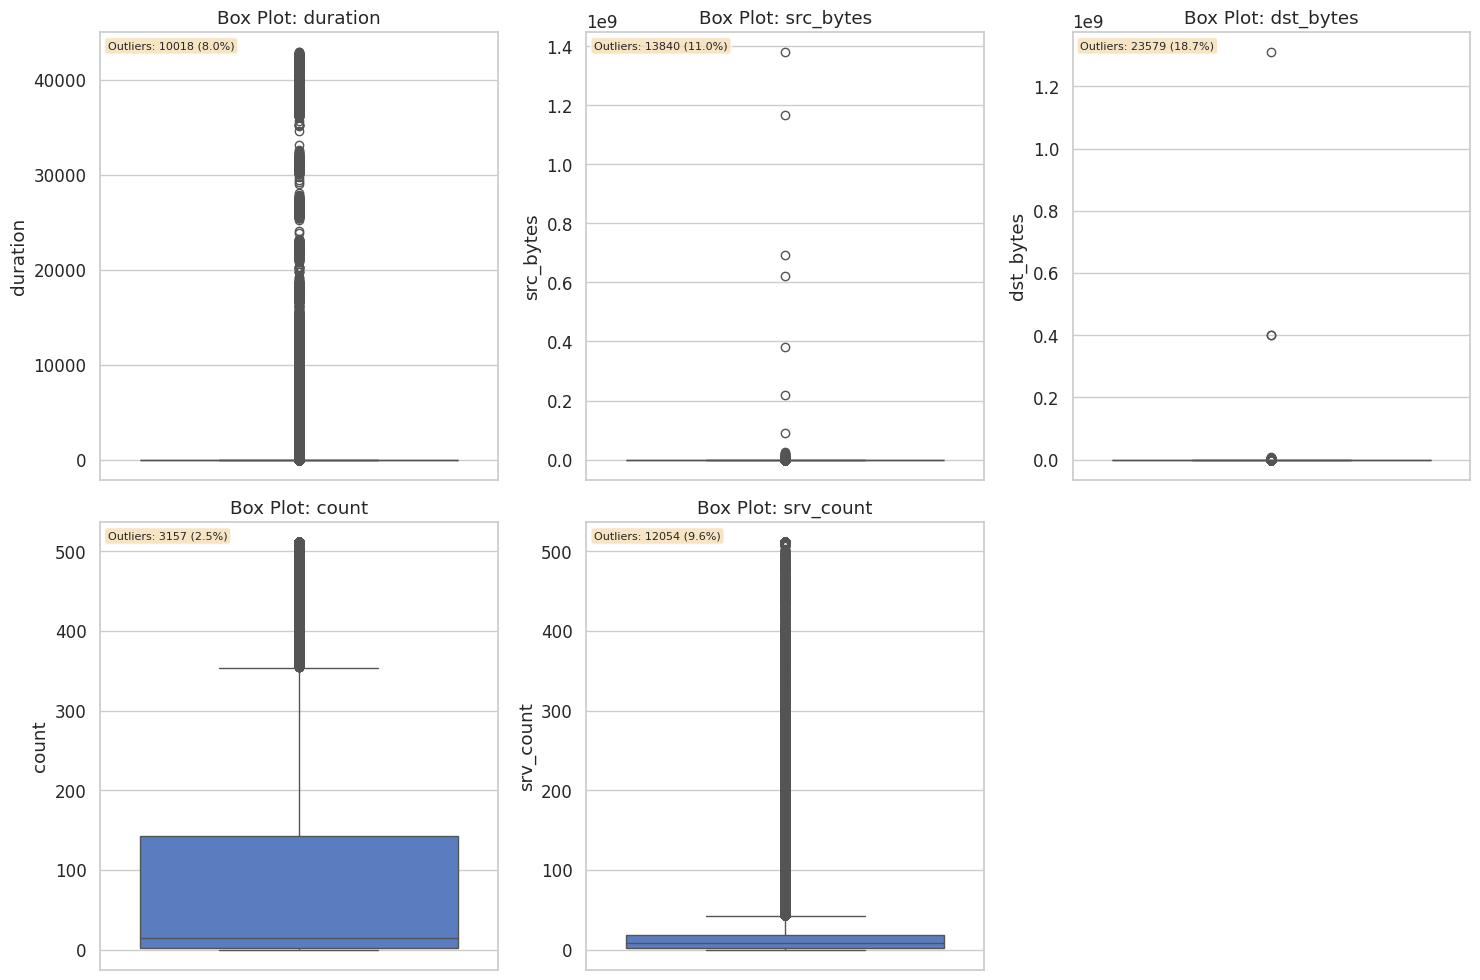

In [17]:
print("\n=== OUTLIER ANALYSIS ===")

def detect_outliers_iqr(df, columns):
    """Detect outliers using IQR method"""
    outlier_info = {}

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_info[col] = {
            'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
            'lower_bound': lower_bound, 'upper_bound': upper_bound,
            'outlier_count': len(outliers),
            'outlier_percentage': (len(outliers) / len(df)) * 100
        }

    return outlier_info

# Analyze outliers for key numerical features
key_numerical_features = ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count']
outlier_info = detect_outliers_iqr(nsl_train_clean, key_numerical_features)

# Plot box plots for outlier visualization
plt.figure(figsize=(15, 10))
for i, col in enumerate(key_numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=nsl_train_clean, y=col)
    plt.title(f'Box Plot: {col}')
    info = outlier_info[col]
    plt.text(0.02, 0.98, f'Outliers: {info["outlier_count"]} ({info["outlier_percentage"]:.1f}%)',
             transform=plt.gca().transAxes, verticalalignment='top', fontsize=8,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()


=== CORRELATION ANALYSIS ===


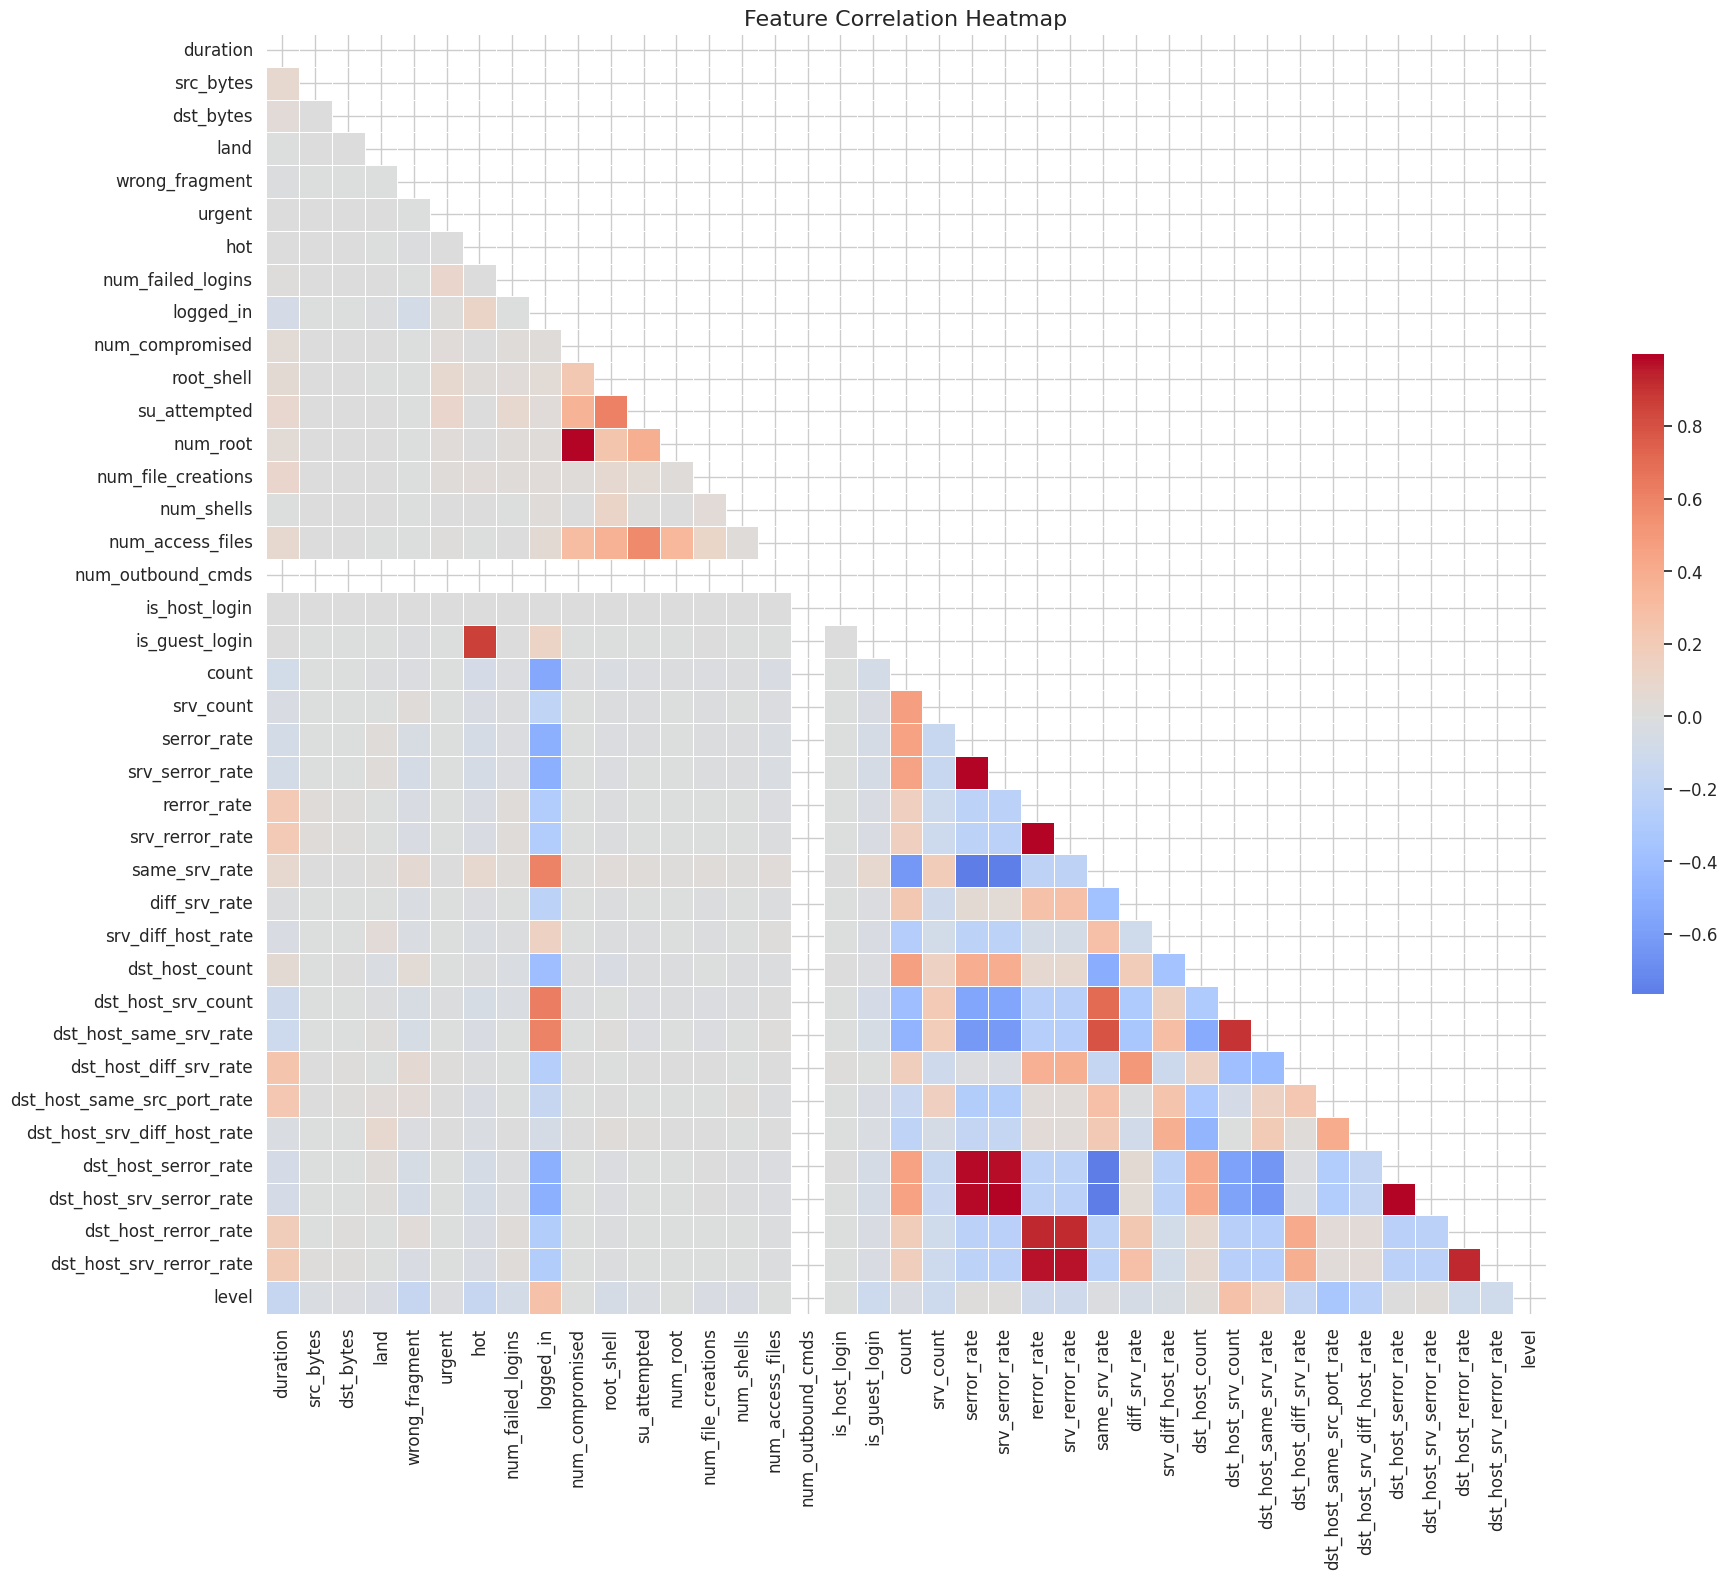

In [22]:
print("\n=== CORRELATION ANALYSIS ===")

# Prepare data for correlation analysis
categorical_cols_to_encode = [col for col in categorical_features if col not in ['level', 'attack_category']]
nsl_encoded = pd.get_dummies(nsl_train_clean, columns=categorical_cols_to_encode, drop_first=True)

# Calculate correlation matrix for numerical features
numerical_cols_for_corr = nsl_encoded.select_dtypes(include=[np.number]).columns
correlation_matrix = nsl_encoded[numerical_cols_for_corr].corr()

# Plot correlation heatmap
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.5})
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

In [23]:
def find_highly_correlated_features(corr_matrix, threshold=0.95):
    """Find pairs of highly correlated features"""
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= threshold:
                high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j],
                                      corr_matrix.iloc[i, j]))
    return high_corr_pairs

high_corr_features = find_highly_correlated_features(correlation_matrix, 0.9)
print(f"Highly correlated feature pairs (>0.9): {len(high_corr_features)}")
for pair in high_corr_features[:10]:  # Show first 10
    print(f"  {pair[0]} - {pair[1]}: {pair[2]:.3f}")

Highly correlated feature pairs (>0.9): 13
  num_compromised - num_root: 0.999
  serror_rate - srv_serror_rate: 0.993
  serror_rate - dst_host_serror_rate: 0.979
  serror_rate - dst_host_srv_serror_rate: 0.981
  srv_serror_rate - dst_host_serror_rate: 0.978
  srv_serror_rate - dst_host_srv_serror_rate: 0.986
  rerror_rate - srv_rerror_rate: 0.989
  rerror_rate - dst_host_rerror_rate: 0.927
  rerror_rate - dst_host_srv_rerror_rate: 0.964
  srv_rerror_rate - dst_host_rerror_rate: 0.918


In [26]:
# 9. FEATURE ENCODING AND PREPROCESSING
print("\n=== FEATURE ENCODING ===")

# Check what columns are available
print("Available columns in nsl_encoded:")
print(nsl_encoded.columns.tolist())
print(f"Shape: {nsl_encoded.shape}")

# Separate features and target
# Drop target columns that exist
columns_to_drop = []
if 'level' in nsl_encoded.columns:
    columns_to_drop.append('level')
if 'attack_category' in nsl_encoded.columns:
    columns_to_drop.append('attack_category')

print(f"Dropping columns: {columns_to_drop}")

X = nsl_encoded.drop(columns_to_drop, axis=1)
y_multiclass = nsl_encoded['attack_category'] if 'attack_category' in nsl_encoded.columns else nsl_train_clean['attack_category']
y_binary = (y_multiclass != 'Normal').astype(int)

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution (multiclass):")
print(y_multiclass.value_counts())


=== FEATURE ENCODING ===
Available columns in nsl_encoded:
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'level', 'attack_category', 'protocol_type_tcp', 'protocol_type_udp', 'service_Other', 'service_Z39_50', 'service_auth', 'service_bgp', 'service_courier', 'service_csnet_ns', 'service_ctf', 'service_daytime', 'service_discard', 'service_domain', '

In [27]:
print("\n=== DISCRETIZATION ===")

def discretize_features(df, features, bins=5):
    """Discretize continuous features"""
    df_discrete = df.copy()
    for feature in features:
        if feature in df.columns:
            df_discrete[f'{feature}_discrete'] = pd.cut(df[feature], bins=bins, labels=False)
    return df_discrete

# Discretize some continuous features
features_to_discretize = ['duration', 'src_bytes', 'dst_bytes']
X_with_discrete = discretize_features(X, features_to_discretize)


=== DISCRETIZATION ===
